In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [2]:
day_1 = pd.read_csv("prices_round_4_day_1.csv", sep=';')
day_2 = pd.read_csv("prices_round_4_day_2.csv", sep=';')
day_3 = pd.read_csv("prices_round_4_day_3.csv", sep=';')


obs_1 = pd.read_csv("observations_round_4_day_1.csv")
obs_2 = pd.read_csv("observations_round_4_day_2.csv")
obs_3 = pd.read_csv("observations_round_4_day_3.csv")

obs_2["timestamp"] += obs_1['timestamp'].max()+1
obs_3["timestamp"] += obs_2['timestamp'].max()+1

day_2['timestamp'] += day_1['timestamp'].max() + 1
day_3['timestamp'] += day_2['timestamp'].max() + 1

combined_df = pd.concat([day_1,day_2,day_3], ignore_index=True)
obs_df = pd.concat([obs_1,obs_2,obs_3], ignore_index=True)



In [3]:
combined_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,VOLCANIC_ROCK,10515.0,143.0,10514.0,57.0,NaN,NaN,10517,200,NaN,NaN,NaN,NaN,10516.0,0.0
1,1,0,PICNIC_BASKET1,58705.0,12.0,58704.0,27.0,NaN,NaN,58716,12,58717.0,27.0,NaN,NaN,58710.5,0.0
2,1,0,PICNIC_BASKET2,30252.0,12.0,30251.0,27.0,NaN,NaN,30258,39,NaN,NaN,NaN,NaN,30255.0,0.0
3,1,0,VOLCANIC_ROCK_VOUCHER_9500,1015.0,12.0,NaN,NaN,NaN,NaN,1017,12,NaN,NaN,NaN,NaN,1016.0,0.0
4,1,0,VOLCANIC_ROCK_VOUCHER_9750,766.0,12.0,NaN,NaN,NaN,NaN,767,12,NaN,NaN,NaN,NaN,766.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449995,3,2999702,JAMS,6446.0,96.0,6445.0,175.0,NaN,NaN,6447,261,NaN,NaN,NaN,NaN,6446.5,0.0
449996,3,2999702,CROISSANTS,4295.0,148.0,NaN,NaN,NaN,NaN,4296,62,4297.0,86.0,NaN,NaN,4295.5,0.0
449997,3,2999702,VOLCANIC_ROCK_VOUCHER_9500,421.0,20.0,NaN,NaN,NaN,NaN,422,20,NaN,NaN,NaN,NaN,421.5,0.0
449998,3,2999702,VOLCANIC_ROCK,9920.0,137.0,9919.0,69.0,NaN,NaN,9921,131,9922.0,69.0,NaN,NaN,9920.5,0.0


In [4]:
def extract_prices(df, symbol):
    filtered = df[df['product'] == symbol]
    prices_only = filtered[['timestamp', 'mid_price']]
    return prices_only

def extract_value(df,symbol):
    return df[['timestamp',symbol]]
     


def calculate_mid_price(row):
    best_bid = row['bid_price_1']
    best_ask = row['ask_price_1']
    
    # Gestion des valeurs manquantes potentielles
    if pd.notna(best_bid) and pd.notna(best_ask):
        return (best_bid + best_ask) / 2
    elif pd.notna(best_bid):
        return best_bid
    elif pd.notna(best_ask):
        return best_ask
    else:
        return None


combined_df['mid_price'] = combined_df.apply(calculate_mid_price, axis=1)

In [5]:
rock_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK')
voucher_9500_mid_prices = extract_prices(combined_df, "VOLCANIC_ROCK_VOUCHER_9500")
voucher_9750_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_9750') 
voucher_10000_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10000')
voucher_10250_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10250')
voucher_10500_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10500')
croissants_prices = extract_prices(combined_df, 'CROISSANTS')
jams_prices = extract_prices(combined_df, 'JAMS')
basket2_prices = extract_prices(combined_df, 'PICNIC_BASKET2')
basket1_prices = extract_prices(combined_df, 'PICNIC_BASKET1')
macarons_mid_prices_exchange = extract_prices(combined_df, 'MAGNIFICENT_MACARONS')


macarons_best_bid = combined_df[combined_df['product'] == "MAGNIFICENT_MACARONS"][["timestamp","bid_price_1"]]
macarons_best_ask=combined_df[combined_df['product'] == "MAGNIFICENT_MACARONS"][["timestamp","ask_price_1"]]


In [6]:
macarons_mid_prices_exchange

,timestamp,mid_price
6,0,627.5
29,100,630.5
41,200,630.5
47,300,632.5
73,400,631.5
...,...,...
449932,2999302,798.0
449940,2999402,802.0
449967,2999502,805.0
449977,2999602,799.0


In [7]:
obs_df.drop(columns=['askPrice','bidPrice'],axis=1)

,timestamp,transportFees,exportTariff,importTariff,sugarPrice,sunlightIndex
0,0,1.0,9.0,-3.0,200.000000,60.00
1,100,1.0,9.0,-3.0,200.098445,60.00
2,200,1.0,9.0,-3.0,200.103915,60.00
3,300,1.0,9.0,-3.0,200.352462,60.01
4,400,1.0,9.0,-3.0,200.201545,60.01
...,...,...,...,...,...,...
29995,2999302,1.7,9.5,-5.5,212.124918,54.95
29996,2999402,1.7,9.5,-5.5,212.147650,54.96
29997,2999502,1.7,9.5,-5.5,212.202086,54.97
29998,2999602,1.7,9.5,-5.5,212.112734,54.98


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


drop_cols = ['bidPrice', 'askPrice','timestamp']

existing_drop_cols = [col for col in drop_cols if col in obs_df.columns]
X = obs_df.drop(columns=existing_drop_cols) 


y = macarons_mid_prices_exchange['mid_price']


feature_columns = list(X.columns)
actual_price_column = y.name if y.name else 'mid_price' 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42) 

# --- Régression Linéaire ---
reg = LinearRegression()
reg.fit(X_train, y_train)

# --- Prédiction sur l'ensemble de test (pour évaluation) ---
y_pred_test = reg.predict(X_test)

# --- Évaluation du modèle ---
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"--- Model evaluation on test set ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"--------------------------------------")


--- Model evaluation on test set ---
Mean Squared Error (MSE): 1883.5636
R² Score: 0.6528
--------------------------------------


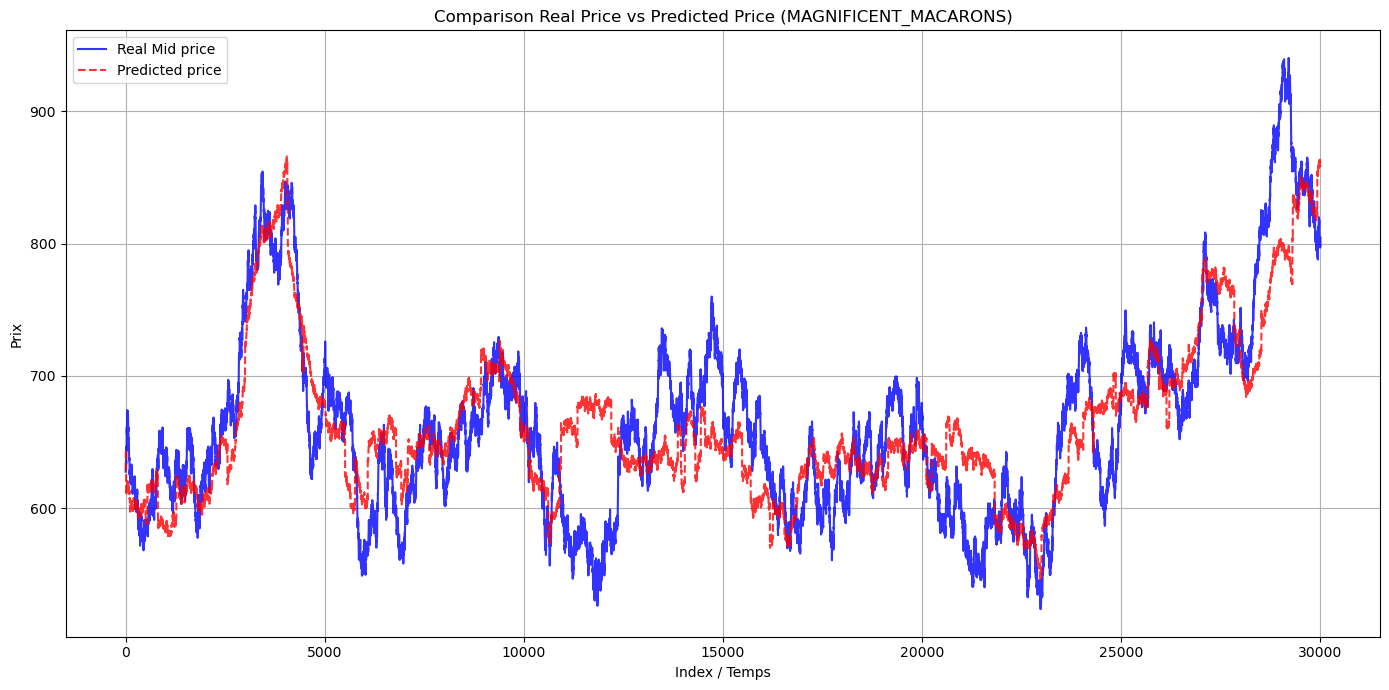


--- Trained Model information ---
Intercept: 663.7680
Coefficients on scaled features:
importTariff    -58.173716
exportTariff    -42.955409
sunlightIndex   -33.997602
sugarPrice       33.576968
transportFees    23.238215
dtype: float64
--------------------------------------


In [9]:
coefficients = reg.coef_
intercept = reg.intercept_


X_full_original = obs_df[feature_columns]


X_full_scaled = scaler.transform(X_full_original)


predicted_prices_full = reg.predict(X_full_scaled)

# --- Ajout au DataFrame et Tracé ---
df_plot = obs_df.copy()

if len(predicted_prices_full) == len(df_plot):
    df_plot['predicted_price'] = predicted_prices_full
actual_prices_to_plot = macarons_mid_prices_exchange['mid_price']
predicted_prices_to_plot = df_plot['predicted_price'] if 'predicted_price' in df_plot.columns else None

plt.figure(figsize=(14, 7)) 

if actual_prices_to_plot is not None:
    plt.plot(df_plot.index, actual_prices_to_plot, label=f'Real Mid price', color='blue', alpha=0.8)

if predicted_prices_to_plot is not None:
    plt.plot(df_plot.index, predicted_prices_to_plot, label='Predicted price', color='red', linestyle='--', alpha=0.8)
else:
     pass

plt.title('Comparison Real Price vs Predicted Price (MAGNIFICENT_MACARONS)')
plt.xlabel('Index / Temps')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.tight_layout() 
plt.show()

print("\n--- Trained Model information ---")
print(f"Intercept: {intercept:.4f}")
coef_series = pd.Series(coefficients, index=feature_columns)
print("Coefficients on scaled features:")
print(coef_series.abs().sort_values(ascending=False).map(lambda x: coef_series[coef_series.abs() == x].iloc[0]))
print(f"--------------------------------------")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


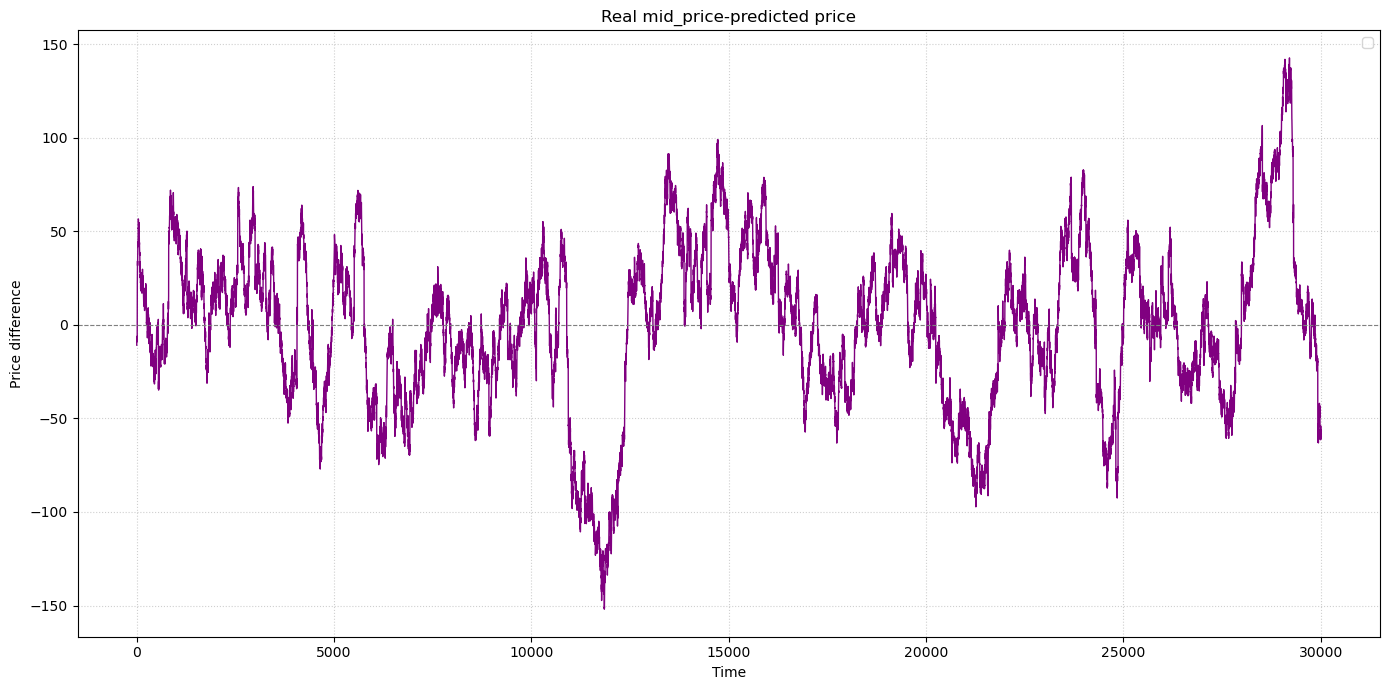

In [10]:
actual_prices = y.values # Utilisation de .values pour soustraction directe
price_difference = actual_prices - predicted_prices_full

plt.figure(figsize=(14, 7))

plt.plot(X.index, price_difference, color='purple', linewidth=1)
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--') 

plt.title('Real mid_price-predicted price')
plt.xlabel('Time')
plt.ylabel('Price difference')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
coefficients_pour_algo = reg.coef_
intercept_pour_algo = reg.intercept_
means_pour_algo = scaler.mean_
scales_pour_algo = scaler.scale_
feature_order_pour_algo = list(X.columns) 

In [12]:
print("--- Paramètres à copier dans l'__init__ de ta classe Trader ---")

print("\n# 1. Exact order of features Features:")
print(f"self.macaron_feature_order = {feature_order_pour_algo}")

print("\n# 2. Scaler means (scaler.mean_):")
print(f"self.macaron_scaler_means = np.array({means_pour_algo.tolist()})") 

print("\n# 3. Scaler standard dev (scaler.scale_):")
print(f"self.macaron_scaler_scales = np.array({scales_pour_algo.tolist()})")

print("\n# 4. regression coeffs(reg.coef_):")
print(f"self.macaron_coeffs = np.array({coefficients_pour_algo.tolist()})")

print("\n# 5. Regression intercept (reg.intercept_):")
print(f"self.macaron_intercept = {intercept_pour_algo}")

--- Paramètres à copier dans l'__init__ de ta classe Trader ---

# 1. Exact order of features Features:
self.macaron_feature_order = ['transportFees', 'exportTariff', 'importTariff', 'sugarPrice', 'sunlightIndex']

# 2. Scaler means (scaler.mean_):
self.macaron_scaler_means = np.array([1.577586666666667, 10.1648, -3.677783333333333, 202.20190148264038, 55.16741833333334])

# 3. Scaler standard dev (scaler.scale_):
self.macaron_scaler_scales = np.array([0.374975078045936, 0.6869674616263375, 1.1110361919047562, 6.707730336044954, 10.326940378366217])

# 4. regression coeffs(reg.coef_):
self.macaron_coeffs = np.array([23.238214562436877, -42.95540901733531, -58.173716296714936, 33.576968413513455, -33.99760244616658])

# 5. Regression intercept (reg.intercept_):
self.macaron_intercept = 663.7679588950559


# RSI

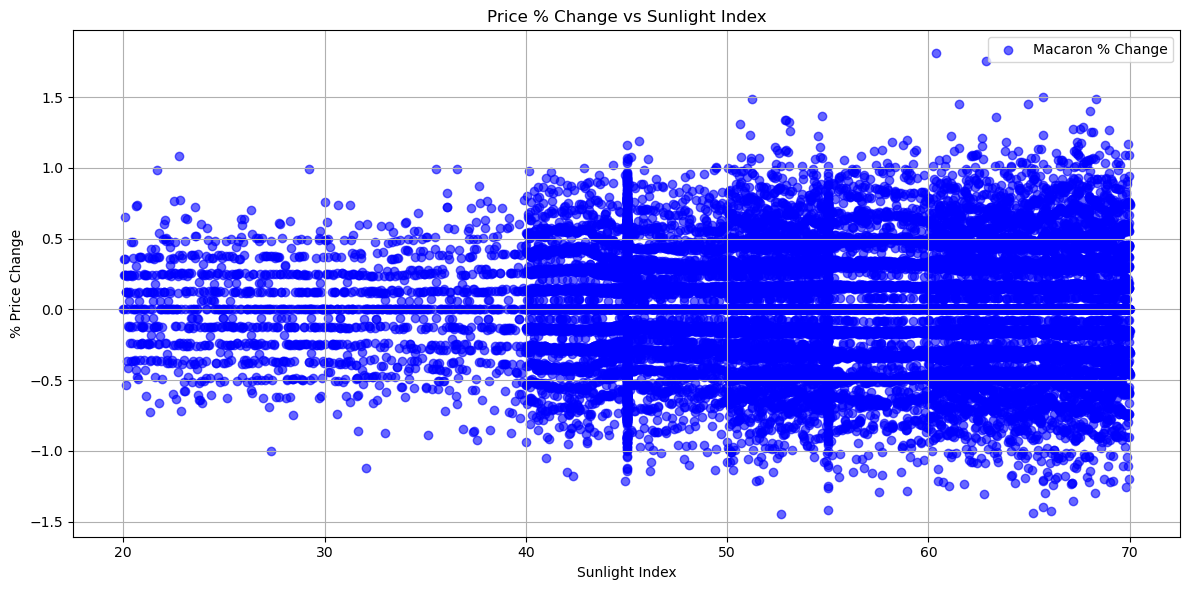

In [15]:
sugar_pct_change = obs_df['sugarPrice'].pct_change() * 100
macaron_pct_change = macarons_mid_prices_exchange['mid_price'].pct_change() * 100


min_len = min(len(sugar_pct_change), len(macaron_pct_change), len(obs_df['sunlightIndex']))
sugar_pct_change = sugar_pct_change[:min_len]
macaron_pct_change = macaron_pct_change[:min_len]
sunlight_index = obs_df['sunlightIndex'][:min_len]

# Tracé
plt.figure(figsize=(12, 6))
plt.scatter(sunlight_index, macaron_pct_change, color='blue', alpha=0.6, label='Macaron % Change')

plt.title('Price % Change vs Sunlight Index')
plt.xlabel('Sunlight Index')
plt.ylabel('% Price Change')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

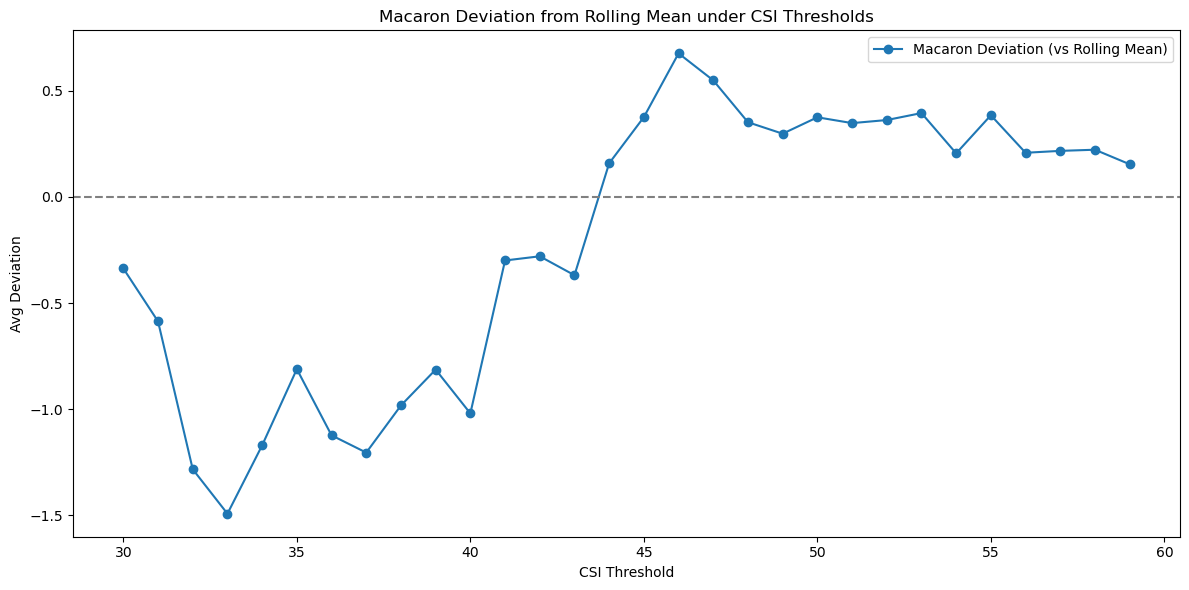

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get the raw values
sunlight = obs_df['sunlightIndex'].values
sugar = obs_df['sugarPrice'].values
macaron = macarons_mid_prices_exchange['mid_price'].values

# Convert to Series to apply rolling
macaron_series = pd.Series(macaron)

# Rolling mean with window size 20
rolling_mean = macaron_series.rolling(window=30, min_periods=1).mean()

# CSI candidates to test
candidate_thresholds = np.arange(30, 60, 1)
avg_macaron_dev = []

for threshold in candidate_thresholds:
    # Mask where sunlight is below threshold
    mask = sunlight < threshold

    if mask.sum() < 10:
        avg_macaron_dev.append(np.nan)
        continue

    # Compute deviation from rolling mean
    macaron_dev = macaron[mask] - rolling_mean[mask].values
    avg_macaron_dev.append(np.mean(macaron_dev))

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(candidate_thresholds, avg_macaron_dev, label='Macaron Deviation (vs Rolling Mean)', marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Macaron Deviation from Rolling Mean under CSI Thresholds")
plt.xlabel("CSI Threshold")
plt.ylabel("Avg Deviation")
plt.legend()
plt.tight_layout()
plt.show()
